# Fase 2 - Limpieza, Dataloaders y Experimentos YOLO

Este notebook prepara una version limpia del dataset, configura dataloaders para inspeccion, visualiza data augmentation y entrena dos experimentos YOLO comparables: uno sin augmentation fuerte y otro con augmentation moderada.

**Principio de seguridad:** el dataset original no se modifica. Toda limpieza se realiza sobre `datasets/radiographs_clean/`.

## 1. Configuracion e imports

In [1]:
from pathlib import Path
from collections import Counter
import random
import shutil
import json
import os

import yaml
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

os.environ.setdefault("POLARS_SKIP_CPU_CHECK", "1")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ORIGINAL_DATASET_DIR = PROJECT_ROOT / "hackathon_TREE_AIBiomed 2"
CLEAN_DATASET_DIR = PROJECT_ROOT / "datasets" / "radiographs_clean"
RESULTS_DIR = PROJECT_ROOT / "results"
RUNS_DIR = PROJECT_ROOT / "runs" / "radiograph_phi_detection"
RANDOM_STATE = 42

CLASS_NAMES = {0: "name", 1: "id", 2: "age", 3: "date", 4: "time"}
CLASS_COLORS = {"name": "#e41a1c", "id": "#377eb8", "age": "#4daf4a", "date": "#984ea3", "time": "#ff7f00"}

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

assert ORIGINAL_DATASET_DIR.exists(), f"No se encuentra el dataset original: {ORIGINAL_DATASET_DIR}"
print("Project root:", PROJECT_ROOT)
print("Original dataset:", ORIGINAL_DATASET_DIR)
print("Clean dataset:", CLEAN_DATASET_DIR)

Project root: /Users/joanvm/Desktop/Projects/Hackathon/HackathonAIBiomed
Original dataset: /Users/joanvm/Desktop/Projects/Hackathon/HackathonAIBiomed/hackathon_TREE_AIBiomed 2
Clean dataset: /Users/joanvm/Desktop/Projects/Hackathon/HackathonAIBiomed/datasets/radiographs_clean


## 2. Limpieza y split balanceado

Acciones:

- Excluir la unica imagen con tamano distinto a 512x512.
- Mantener el dataset original intacto.
- Crear una copia limpia compatible con YOLO.
- Balancear la proporcion de imagenes con `time` entre train y val mediante un intercambio determinista.

In [2]:
def image_base_id(image_path):
    stem = image_path.stem
    suffix = "_annotated"
    return stem[:-len(suffix)] if stem.endswith(suffix) else stem


def label_for_original_image(image_path, split):
    return ORIGINAL_DATASET_DIR / "labels" / split / f"{image_base_id(image_path)}.txt"


def read_classes(label_path):
    return [int(line.split()[0]) for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]


def collect_original_records():
    records = []
    for split in ["train", "val"]:
        for image_path in sorted((ORIGINAL_DATASET_DIR / "images" / split).glob("*.png")):
            label_path = label_for_original_image(image_path, split)
            with Image.open(image_path) as img:
                width, height = img.size
            classes = read_classes(label_path)
            records.append({
                "image_id": image_base_id(image_path),
                "image_path": image_path,
                "label_path": label_path,
                "original_split": split,
                "width": width,
                "height": height,
                "has_time": 4 in classes,
                "classes": classes,
            })
    return records


def choose_balanced_split(records):
    filtered = [record for record in records if (record["width"], record["height"]) == (512, 512)]
    removed = [record for record in records if (record["width"], record["height"]) != (512, 512)]

    train_records = [record for record in filtered if record["original_split"] == "train"]
    val_records = [record for record in filtered if record["original_split"] == "val"]
    train_time = [record for record in train_records if record["has_time"]]
    val_no_time = [record for record in val_records if not record["has_time"]]

    rng = random.Random(RANDOM_STATE)
    move_time_to_val = set(record["image_id"] for record in rng.sample(train_time, 3))
    move_no_time_to_train = set(record["image_id"] for record in rng.sample(val_no_time, 3))

    split_by_id = {}
    for record in filtered:
        new_split = record["original_split"]
        if record["image_id"] in move_time_to_val:
            new_split = "val"
        elif record["image_id"] in move_no_time_to_train:
            new_split = "train"
        split_by_id[record["image_id"]] = new_split
    return filtered, removed, split_by_id, move_time_to_val, move_no_time_to_train


records = collect_original_records()
filtered_records, removed_records, split_by_id, moved_time_to_val, moved_no_time_to_train = choose_balanced_split(records)

print("Imagenes originales:", len(records))
print("Imagenes limpias:", len(filtered_records))
print("Imagenes eliminadas por tamano:", [record["image_path"].name for record in removed_records])
print("Train con time movidas a val:", sorted(moved_time_to_val))
print("Val sin time movidas a train:", sorted(moved_no_time_to_train))

Imagenes originales: 400
Imagenes limpias: 399
Imagenes eliminadas por tamano: ['6e49ab6e-321fee4e-20c6780b-554d4570-0d8a5012_annotated.png']
Train con time movidas a val: ['0c27f551-2cc6bf3e-a2e2cabd-97973771-40f1e6ce', '1fe73f8e-036bd24e-4578c891-33c1746e-864884a7', 'c0fabcc0-d992f499-b7a8fa49-58bc6411-cb804475']
Val sin time movidas a train: ['3d41d0fb-e3da9f63-0918d00a-5e0c6805-a99018cd', '4b00acf0-a59615c4-6d607a0c-e6ee01b7-177c175f', 'e0275ad1-1e6a7451-c3960f5f-1267a188-547b73a1']


In [3]:
def reset_clean_dataset():
    if CLEAN_DATASET_DIR.exists():
        shutil.rmtree(CLEAN_DATASET_DIR)
    for split in ["train", "val"]:
        (CLEAN_DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (CLEAN_DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)


def copy_record_to_clean_dataset(record, new_split):
    target_image = CLEAN_DATASET_DIR / "images" / new_split / record["image_path"].name
    target_label = CLEAN_DATASET_DIR / "labels" / new_split / f"{record['image_path'].stem}.txt"
    shutil.copy2(record["image_path"], target_image)
    shutil.copy2(record["label_path"], target_label)


def write_clean_data_yaml():
    data_yaml = {
        "path": str(CLEAN_DATASET_DIR.resolve()),
        "train": "images/train",
        "val": "images/val",
        "nc": len(CLASS_NAMES),
        "names": CLASS_NAMES,
    }
    with (CLEAN_DATASET_DIR / "data.yaml").open("w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=False)
    return CLEAN_DATASET_DIR / "data.yaml"


reset_clean_dataset()
for record in filtered_records:
    copy_record_to_clean_dataset(record, split_by_id[record["image_id"]])
CLEAN_DATA_YAML = write_clean_data_yaml()
print("Dataset limpio creado en:", CLEAN_DATASET_DIR)
print("data.yaml:", CLEAN_DATA_YAML)

Dataset limpio creado en: /Users/joanvm/Desktop/Projects/Hackathon/HackathonAIBiomed/datasets/radiographs_clean
data.yaml: /Users/joanvm/Desktop/Projects/Hackathon/HackathonAIBiomed/datasets/radiographs_clean/data.yaml


In [4]:
def summarize_clean_dataset():
    rows = []
    for split in ["train", "val"]:
        for image_path in sorted((CLEAN_DATASET_DIR / "images" / split).glob("*.png")):
            label_path = CLEAN_DATASET_DIR / "labels" / split / f"{image_path.stem}.txt"
            classes = read_classes(label_path)
            with Image.open(image_path) as img:
                width, height = img.size
            rows.append({
                "split": split,
                "image_name": image_path.name,
                "label_name": label_path.name,
                "label_exists": label_path.exists(),
                "width": width,
                "height": height,
                "has_time": 4 in classes,
                "n_boxes": len(classes),
            })
    return pd.DataFrame(rows)


clean_df = summarize_clean_dataset()
display(clean_df.groupby("split").agg(images=("image_name", "count"), with_time=("has_time", "sum"), boxes=("n_boxes", "sum")))
display(clean_df.groupby(["split", "width", "height"]).size().reset_index(name="n_images"))

assert len(clean_df) == 399
assert clean_df["label_exists"].all()
assert (clean_df.groupby("split").size().to_dict() == {"train": 319, "val": 80})
assert clean_df.groupby("split")["has_time"].sum().to_dict() == {"train": 106, "val": 27}
assert set(zip(clean_df["width"], clean_df["height"])) == {(512, 512)}
print("Validacion del dataset derivado completada.")

,images,with_time,boxes
split,,,
train,319,106,1382
val,80,27,347


,split,width,height,n_images
0,train,512,512,319
1,val,512,512,80


Validacion del dataset derivado completada.


## 3. Dataloaders normal y augmentado

Estos dataloaders se usan para inspeccion visual y sanity checks. El entrenamiento principal se hara con Ultralytics YOLO, que tiene su propio dataloader interno.

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A


def yolo_to_xyxy(row, image_width, image_height):
    class_id, x_center, y_center, box_width, box_height = row
    x_center *= image_width
    y_center *= image_height
    box_width *= image_width
    box_height *= image_height
    return [x_center - box_width / 2, y_center - box_height / 2, x_center + box_width / 2, y_center + box_height / 2]


def read_yolo_boxes(label_path, width, height):
    boxes, labels = [], []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        values = [float(part) for part in line.split()]
        labels.append(int(values[0]))
        boxes.append(yolo_to_xyxy(values, width, height))
    return boxes, labels


class RadiographYoloDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.transform = transform
        self.image_paths = sorted((self.root_dir / "images" / split).glob("*.png"))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label_path = self.root_dir / "labels" / self.split / f"{image_path.stem}.txt"
        image = np.array(Image.open(image_path).convert("RGB"))
        height, width = image.shape[:2]
        boxes, labels = read_yolo_boxes(label_path, width, height)

        if self.transform is not None:
            transformed = self.transform(image=image, bboxes=boxes, class_labels=labels)
            image = transformed["image"]
            boxes = list(transformed["bboxes"])
            labels = list(transformed["class_labels"])

        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_path": str(image_path),
        }
        return image_tensor, target


def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


def compression_transform():
    try:
        return A.ImageCompression(quality_range=(55, 95), p=1.0)
    except TypeError:
        return A.ImageCompression(quality_lower=55, quality_upper=95, p=1.0)


normal_dataset = RadiographYoloDataset(CLEAN_DATASET_DIR, split="train")
normal_loader = DataLoader(normal_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

augmentation_for_loader = A.Compose(
    [
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.8),
        A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),
        compression_transform(),
        A.Affine(scale=(0.95, 1.05), translate_percent=(-0.03, 0.03), rotate=(-1, 1), p=0.8),
    ],
    bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"], min_visibility=0.3),
)
augmented_dataset = RadiographYoloDataset(CLEAN_DATASET_DIR, split="train", transform=augmentation_for_loader)
augmented_loader = DataLoader(augmented_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

images, targets = next(iter(normal_loader))
aug_images, aug_targets = next(iter(augmented_loader))
print("Batch normal:", len(images), images[0].shape, targets[0]["boxes"].shape)
print("Batch augmentado:", len(aug_images), aug_images[0].shape, aug_targets[0]["boxes"].shape)
assert targets[0]["boxes"].numel() > 0
assert torch.all(aug_targets[0]["boxes"] >= 0)
assert torch.all(aug_targets[0]["boxes"][:, [0, 2]] <= 512)
assert torch.all(aug_targets[0]["boxes"][:, [1, 3]] <= 512)

Batch normal: 4 torch.Size([3, 512, 512]) torch.Size([4, 4])
Batch augmentado: 4 torch.Size([3, 512, 512]) torch.Size([5, 4])


/var/folders/c2/v_b8zqgs6k30r23z7j0ljmkh0000gn/T/ipykernel_59524/1624663560.py:76: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),


## 4. Visualizacion de augmentations

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
/var/folders/c2/v_b8zqgs6k30r23z7j0ljmkh0000gn/T/ipykernel_59524/1754622438.py:21: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  "ruido_leve": A.Compose([A.GaussNoise(var_limit=(5.0, 35.0), p=1.0)], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"])),


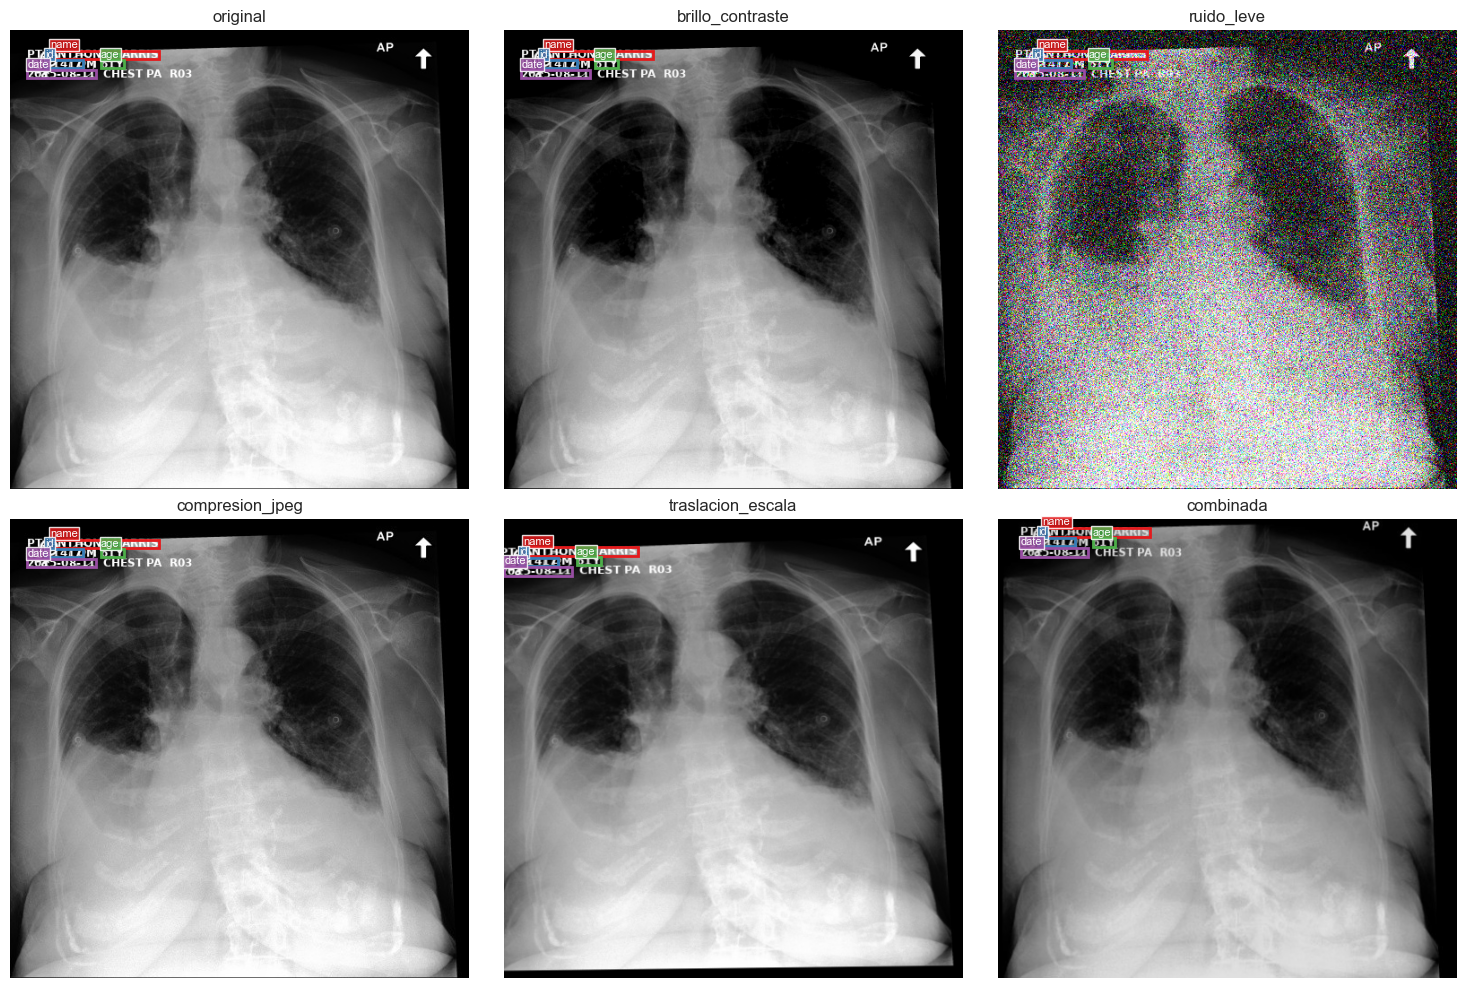

Preview guardada en: /Users/joanvm/Desktop/Projects/Hackathon/HackathonAIBiomed/results/augmentation_preview.png


In [7]:
def tensor_to_image(image_tensor):
    return (image_tensor.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)


def draw_boxes(ax, image, boxes, labels, title):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")
    for box, label in zip(boxes, labels):
        class_name = CLASS_NAMES[int(label)]
        color = CLASS_COLORS[class_name]
        x1, y1, x2, y2 = [float(v) for v in box]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 3), class_name, color="white", fontsize=8, bbox={"facecolor": color, "alpha": 0.85, "pad": 1})


single_transforms = {
    "original": None,
    "brillo_contraste": A.Compose([A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0)], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"])),
    "ruido_leve": A.Compose([A.GaussNoise(var_limit=(5.0, 35.0), p=1.0)], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"])),
    "compresion_jpeg": A.Compose([compression_transform()], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"])),
    "traslacion_escala": A.Compose([A.Affine(scale=(0.95, 1.05), translate_percent=(-0.03, 0.03), rotate=(-1, 1), p=1.0)], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"])),
    "combinada": augmentation_for_loader,
}

sample_image_path = normal_dataset.image_paths[0]
base_image = np.array(Image.open(sample_image_path).convert("RGB"))
base_boxes, base_labels = read_yolo_boxes(CLEAN_DATASET_DIR / "labels" / "train" / f"{sample_image_path.stem}.txt", 512, 512)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (name, transform) in zip(axes.flat, single_transforms.items()):
    if transform is None:
        image, boxes, labels = base_image, base_boxes, base_labels
    else:
        transformed = transform(image=base_image, bboxes=base_boxes, class_labels=base_labels)
        image, boxes, labels = transformed["image"], transformed["bboxes"], transformed["class_labels"]
    draw_boxes(ax, image, boxes, labels, name)
plt.tight_layout()
preview_path = RESULTS_DIR / "augmentation_preview.png"
plt.savefig(preview_path, dpi=160, bbox_inches="tight")
plt.show()
print("Preview guardada en:", preview_path)

## 5. Configuracion YOLO, entrenamiento, validacion y test

In [8]:
from ultralytics import YOLO


def choose_device():
    if torch.cuda.is_available():
        return 0
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        print("MPS detectado, pero se usara CPU por compatibilidad con autocast/Ultralytics en este entorno.")
        return "cpu"
    return "cpu"


def load_base_yolo_model():
    errors = []
    for model_name in ["yolo11n.pt", "yolov8n.pt"]:
        try:
            return YOLO(model_name), model_name
        except Exception as exc:
            errors.append(f"{model_name}: {exc}")
    raise RuntimeError("No se pudo cargar ningun modelo base: " + " | ".join(errors))


DEVICE = choose_device()
print("Device seleccionado:", DEVICE)

NORMAL_AUG_ARGS = {
    "hsv_h": 0.0, "hsv_s": 0.0, "hsv_v": 0.0,
    "degrees": 0.0, "translate": 0.0, "scale": 0.0, "shear": 0.0, "perspective": 0.0,
    "flipud": 0.0, "fliplr": 0.0, "mosaic": 0.0, "mixup": 0.0, "copy_paste": 0.0,
}

AUGMENTED_AUG_ARGS = {
    "hsv_h": 0.0, "hsv_s": 0.0, "hsv_v": 0.15,
    "degrees": 1.0, "translate": 0.03, "scale": 0.10, "shear": 0.0, "perspective": 0.0,
    "flipud": 0.0, "fliplr": 0.0, "mosaic": 0.2, "mixup": 0.0, "copy_paste": 0.0,
}

TRAINING_ARGS = {
    "data": str(CLEAN_DATA_YAML),
    "imgsz": 640,
    "epochs": 20,
    "patience": 5,
    "batch": -1,
    "device": DEVICE,
    "optimizer": "auto",
    "amp": False,
    "project": str(RUNS_DIR),
    "plots": True,
    "seed": RANDOM_STATE,
    "deterministic": True,
    "workers": 0,
    "exist_ok": True,
    "verbose": True,
}

MPS detectado, pero se usara CPU por compatibilidad con autocast/Ultralytics en este entorno.
Device seleccionado: cpu


In [9]:
def extract_metrics(metrics, experiment_name):
    box = metrics.box
    row = {
        "experiment": experiment_name,
        "map50": float(box.map50),
        "map50_95": float(box.map),
        "precision": float(np.nanmean(np.asarray(box.p, dtype=float))),
        "recall": float(np.nanmean(np.asarray(box.r, dtype=float))),
    }
    p_values = np.asarray(box.p, dtype=float)
    r_values = np.asarray(box.r, dtype=float)
    maps_values = np.asarray(box.maps, dtype=float)
    for class_id, class_name in CLASS_NAMES.items():
        if class_id < len(p_values):
            row[f"precision_{class_name}"] = float(p_values[class_id])
        if class_id < len(r_values):
            row[f"recall_{class_name}"] = float(r_values[class_id])
        if class_id < len(maps_values):
            row[f"map50_95_{class_name}"] = float(maps_values[class_id])
    return row


def train_yolo_experiment(experiment_name, augmentation_args):
    model, base_model_name = load_base_yolo_model()
    args = dict(TRAINING_ARGS)
    args.update(augmentation_args)
    args["name"] = experiment_name
    print(f"Entrenando {experiment_name} desde {base_model_name}")
    train_results = model.train(**args)
    val_metrics = model.val(data=str(CLEAN_DATA_YAML), imgsz=640, batch=16, device=DEVICE, plots=True, project=str(RUNS_DIR), name=f"{experiment_name}_val", exist_ok=True)
    metrics_row = extract_metrics(val_metrics, experiment_name)
    metrics_row["base_model"] = base_model_name
    metrics_row["run_dir"] = str(RUNS_DIR / experiment_name)
    return model, train_results, val_metrics, metrics_row


def validate_model(model, experiment_name):
    return model.val(data=str(CLEAN_DATA_YAML), imgsz=640, batch=16, device=DEVICE, plots=True, project=str(RUNS_DIR), name=f"{experiment_name}_val_manual", exist_ok=True)


def test_model(model, experiment_name):
    # No hay split test independiente. Para el MVP, esta funcion evalua sobre val y deja el punto de extension preparado.
    return model.val(data=str(CLEAN_DATA_YAML), split="val", imgsz=640, batch=16, device=DEVICE, plots=True, project=str(RUNS_DIR), name=f"{experiment_name}_test_proxy", exist_ok=True)

## 6. Ejecucion de experimentos

Esta celda entrena dos modelos: `normal` y `augmented`. Si solo se quiere revisar el notebook sin entrenar, cambiar `RUN_TRAINING` a `False`.

In [10]:
RUN_TRAINING = True

metrics_rows = []
trained_models = {}

if RUN_TRAINING:
    normal_model, normal_train_results, normal_val_metrics, normal_metrics = train_yolo_experiment("normal", NORMAL_AUG_ARGS)
    augmented_model, augmented_train_results, augmented_val_metrics, augmented_metrics = train_yolo_experiment("augmented", AUGMENTED_AUG_ARGS)
    trained_models["normal"] = normal_model
    trained_models["augmented"] = augmented_model
    metrics_rows.extend([normal_metrics, augmented_metrics])

    metrics_df = pd.DataFrame(metrics_rows)
    metrics_path = RESULTS_DIR / "metrics_summary.csv"
    metrics_df.to_csv(metrics_path, index=False)
    display(metrics_df)
    print("Metricas guardadas en:", metrics_path)
else:
    print("RUN_TRAINING=False. Las funciones de entrenamiento quedan preparadas, pero no se ejecutan experimentos.")

Entrenando normal desde yolo11n.pt
Ultralytics 8.4.63 🚀 Python-3.12.8 torch-2.11.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/joanvm/Desktop/Projects/Hackathon/HackathonAIBiomed/datasets/radiographs_clean/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=normal, nbs=64, nms=Fals

,experiment,map50,map50_95,precision,recall,precision_name,recall_name,map50_95_name,precision_id,recall_id,...,recall_age,map50_95_age,precision_date,recall_date,map50_95_date,precision_time,recall_time,map50_95_time,base_model,run_dir
0,normal,0.926324,0.862521,0.840876,0.896584,0.746368,0.975,0.840419,0.986498,0.913268,...,0.895247,0.925066,0.720127,0.975,0.904936,0.765160,0.724406,0.712372,yolo11n.pt,/Users/joanvm/Desktop/Projects/Hackathon/Hacka...
1,augmented,0.990725,0.889994,0.994984,0.977685,0.997804,1.000,0.812007,0.996693,1.000000,...,0.987500,0.905862,0.996042,0.975,0.895274,0.988099,0.925926,0.893358,yolo11n.pt,/Users/joanvm/Desktop/Projects/Hackathon/Hacka...


Metricas guardadas en: /Users/joanvm/Desktop/Projects/Hackathon/HackathonAIBiomed/results/metrics_summary.csv


## 7. Comparacion y discusion automatica

La discusion se genera a partir de `results/metrics_summary.csv` cuando los experimentos ya se han ejecutado.

In [11]:
metrics_path = RESULTS_DIR / "metrics_summary.csv"
if metrics_path.exists():
    metrics_df = pd.read_csv(metrics_path)
    display(metrics_df)
    normal = metrics_df[metrics_df["experiment"] == "normal"].iloc[0]
    augmented = metrics_df[metrics_df["experiment"] == "augmented"].iloc[0]

    recall_delta = augmented["recall"] - normal["recall"]
    precision_delta = augmented["precision"] - normal["precision"]
    map_delta = augmented["map50_95"] - normal["map50_95"]
    time_recall_delta = augmented.get("recall_time", np.nan) - normal.get("recall_time", np.nan)

    print("Discusion para report/video")
    print("- El objetivo principal es maximizar recall, porque dejar informacion sensible visible es mas grave que tapar de mas.")
    print(f"- Cambio de recall global con augmentation: {recall_delta:+.4f}")
    print(f"- Cambio de precision global con augmentation: {precision_delta:+.4f}")
    print(f"- Cambio de mAP50-95 con augmentation: {map_delta:+.4f}")
    if not np.isnan(time_recall_delta):
        print(f"- Cambio de recall en la clase time: {time_recall_delta:+.4f}")
    if recall_delta >= 0 and precision_delta > -0.05:
        print("- Recomendacion: usar el experimento augmentado como baseline para la app.")
    elif normal["recall"] >= augmented["recall"]:
        print("- Recomendacion: mantener el experimento normal como baseline y revisar augmentations mas suaves.")
    else:
        print("- Recomendacion: revisar visualmente falsos positivos antes de decidir baseline.")
else:
    print("Todavia no existe metrics_summary.csv. Ejecuta la celda de entrenamiento para generar la comparacion.")

,experiment,map50,map50_95,precision,recall,precision_name,recall_name,map50_95_name,precision_id,recall_id,...,recall_age,map50_95_age,precision_date,recall_date,map50_95_date,precision_time,recall_time,map50_95_time,base_model,run_dir
0,normal,0.926324,0.862521,0.840876,0.896584,0.746368,0.975,0.840419,0.986498,0.913268,...,0.895247,0.925066,0.720127,0.975,0.904936,0.765160,0.724406,0.712372,yolo11n.pt,/Users/joanvm/Desktop/Projects/Hackathon/Hacka...
1,augmented,0.990725,0.889994,0.994984,0.977685,0.997804,1.000,0.812007,0.996693,1.000000,...,0.987500,0.905862,0.996042,0.975,0.895274,0.988099,0.925926,0.893358,yolo11n.pt,/Users/joanvm/Desktop/Projects/Hackathon/Hacka...


Discusion para report/video
- El objetivo principal es maximizar recall, porque dejar informacion sensible visible es mas grave que tapar de mas.
- Cambio de recall global con augmentation: +0.0811
- Cambio de precision global con augmentation: +0.1541
- Cambio de mAP50-95 con augmentation: +0.0275
- Cambio de recall en la clase time: +0.2015
- Recomendacion: usar el experimento augmentado como baseline para la app.
